(glossary:ellipse_fitting:code)=
# Ellipsoid fitting

Napari-stress implements several algorithms for ellipse fitting. They all have in common that they return a napari [vectors layer](https://napari.org/stable/howtos/layers/vectors.html) which represents the three major axes of the fitted ellipsoid. Napari-stress provides some further functionality to project the input pointcloud onto the surface of the fitted ellipsoid.

* [Napari-stress implementation](#napari-stress) Least squares ellipsoid fitting
* [Vedo implementation](#vedo) Statistical ellipsoid fitting
* [Quantification](#quality) Quantify fit quality
* [Mean curvature](#mean_curvature) Measure mean curvature on ellipsoid

In [1]:
import matplotlib.pyplot as plt
import napari

import napari_stress
from napari_stress import approximation, measurements, vectors

In [2]:
viewer = napari.Viewer(ndisplay=3)

## Napari-stress implementation <a class="anchor" id="napari-stress"></a>

This is a [least-squares](https://en.wikipedia.org/wiki/Least_squares) approach at ellipse fitting.

In [3]:
pointcloud = napari_stress.get_droplet_point_cloud()[0][0][:, 1:]

expander = approximation.EllipsoidExpander()
expander.fit(pointcloud)

ellipsoid_stress = expander.coefficients_

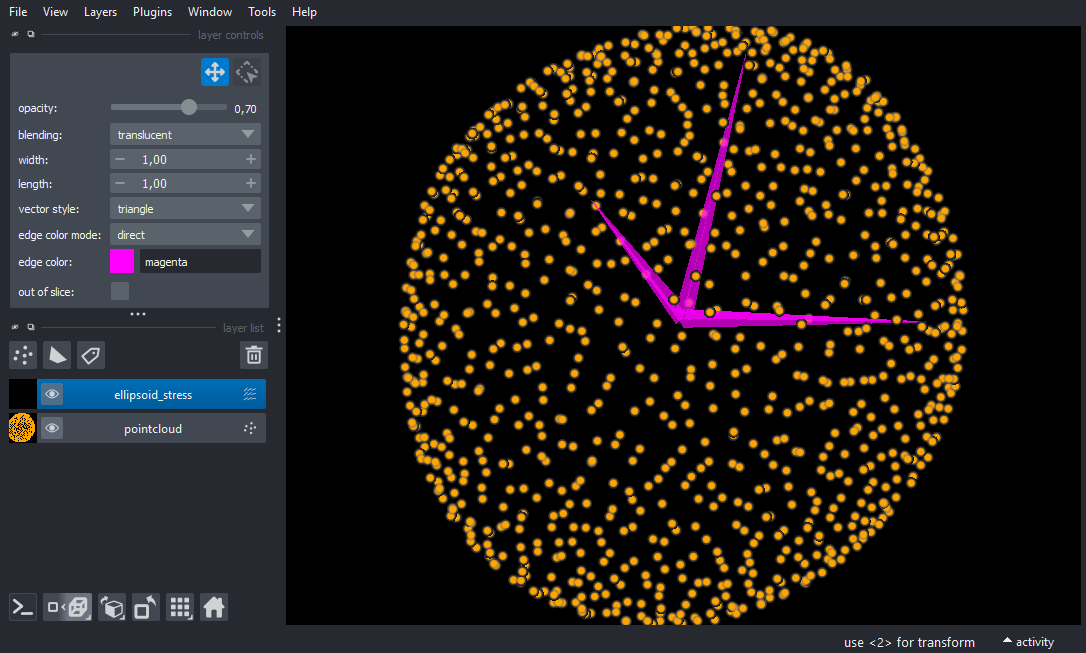

In [4]:
viewer.layers.clear()
viewer.add_points(pointcloud, size=0.5, face_color='orange')
viewer.add_vectors(ellipsoid_stress, edge_width=1, edge_color='magenta')
napari.utils.nbscreenshot(viewer)

To display, where the initial input points would fall on the surface of the fitted ellipse, use the `EllipsoidExpander`'s `fit_expand()` function:

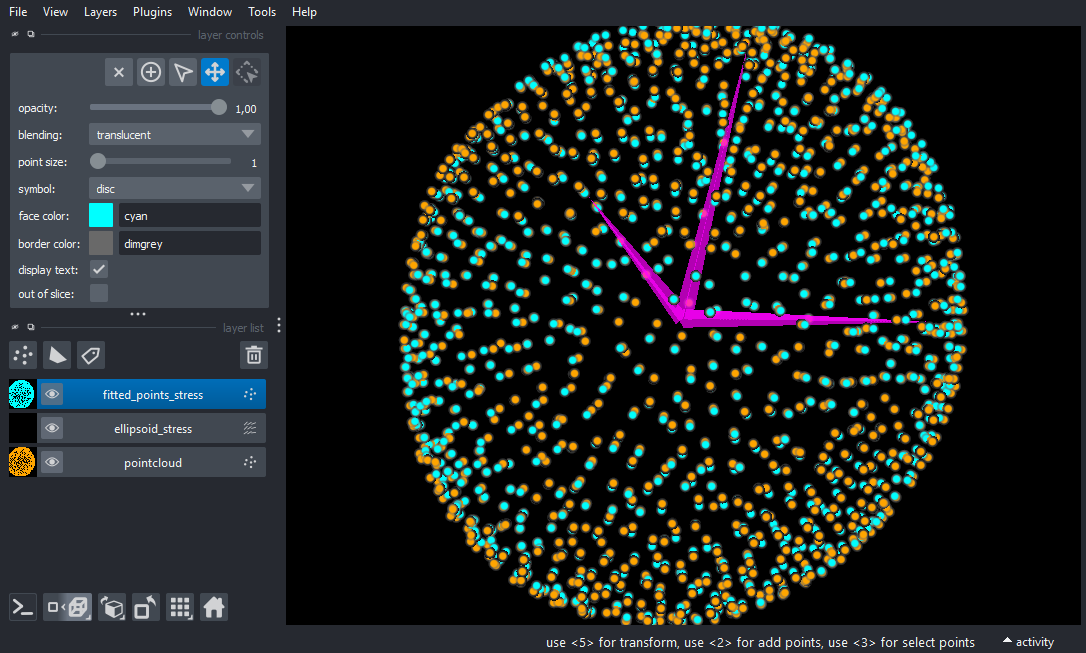

In [5]:
fitted_points_stress = expander.fit_expand(pointcloud)
viewer.add_points(fitted_points_stress, size=0.5, face_color='cyan')
napari.utils.nbscreenshot(viewer)

To display the corresponding normal vectors, simply retrieve them from the `properties` of the `EllipsoidExpander`:

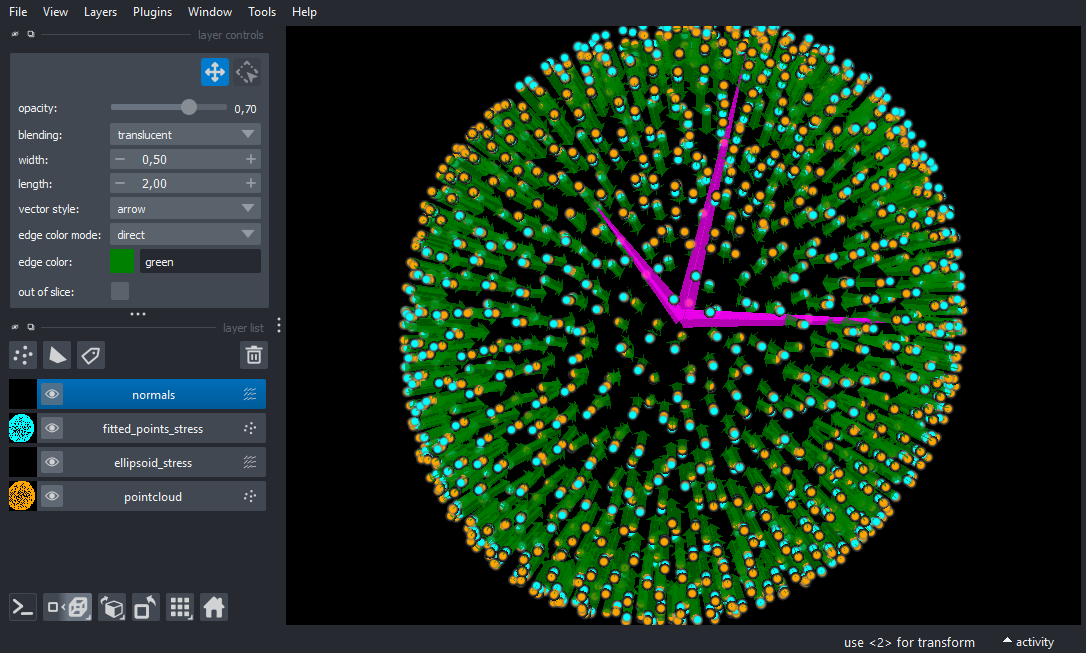

In [14]:
normals = expander.properties['normals']
viewer.add_vectors(normals, edge_color='green', length=2, vector_style='arrow', edge_width=0.5)
napari.utils.nbscreenshot(viewer)

## Vedo implementation <a class="anchor" id="vedo"></a>
This function re-implements the [respective function](https://vedo.embl.es/autodocs/content/vedo/pointcloud.html#vedo.pointcloud.pcaEllipsoid) from the vedo library. It applies a [PCA-algorithm](https://en.wikipedia.org/wiki/Principal_component_analysis) to a pointcloud to retrieve the major and minor axises of an ellipsoid, that comprises a set fraction of points within its volumne. The `inside_fraction` parameter controls how many points of the pointcloud will be located within the volume of the determined ellipsoid.

In [15]:
ellipsoid_vedo = napari_stress.fit_ellipsoid_to_pointcloud_vectors(pointcloud, inside_fraction=0.675)
expander.coefficients_ = ellipsoid_vedo
fitted_points_vedo = expander.expand(pointcloud)

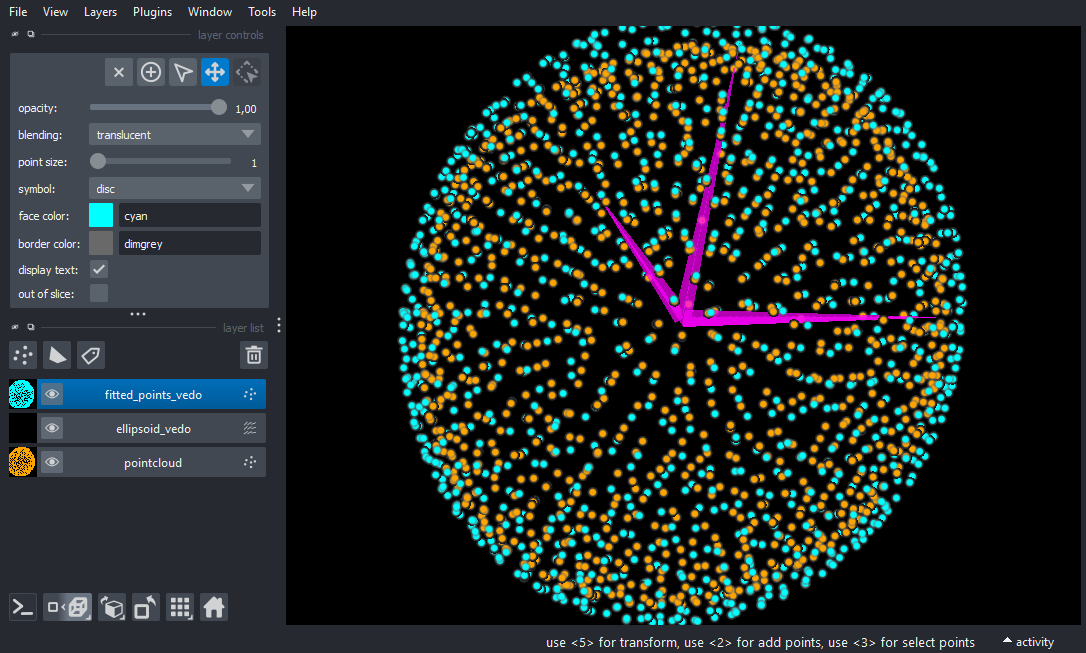

In [16]:
viewer.layers.clear()
viewer.add_points(pointcloud, size=0.5, face_color='orange')
viewer.add_vectors(ellipsoid_vedo, edge_width=1, edge_color='magenta')
viewer.add_points(fitted_points_vedo, size=0.5, face_color='cyan')
napari.utils.nbscreenshot(viewer)

## Fit quality quantification <a class="anchor" id="quality"></a>

Lastly, if you wanted to quantify the fit remainder (i.e., the distance between the input and the fitted points), you can do this directly using the provided `EllipsoidExpander` object':

In [17]:
expander.properties

{'residuals': array([0.96557094, 1.02913339, 1.01736608, ..., 1.16384485, 0.86929885,
        1.00748116]),
 'maximum_mean_curvature': 0.07505048474496134,
 'minimum_mean_curvature': 0.052514205088737574,
 'normals': array([[[ 2.75304514e+01,  3.30434020e+01,  2.15441396e+01],
         [ 1.79512885e-01,  1.06088104e-01,  9.78018629e-01]],
 
        [[ 2.86567037e+01,  3.37242714e+01,  2.14134405e+01],
         [ 9.61564762e-02,  5.82442479e-02,  9.93660676e-01]],
 
        [[ 2.79063860e+01,  3.50012782e+01,  2.14640833e+01],
         [ 1.37374254e-01, -8.06209499e-03,  9.90486404e-01]],
 
        ...,
 
        [[ 3.10338097e+01,  3.38254091e+01,  5.09304402e+01],
         [-1.34973298e-01, -1.05700950e-01, -9.85195168e-01]],
 
        [[ 2.89796776e+01,  3.50643816e+01,  5.11848308e+01],
         [-1.53345084e-03, -1.56136240e-01, -9.87734338e-01]],
 
        [[ 3.03534090e+01,  3.54564932e+01,  5.09277742e+01],
         [-1.00833131e-01, -1.90476649e-01, -9.76499527e-01]]])}

You can calculate the length of these vectors using numpy:

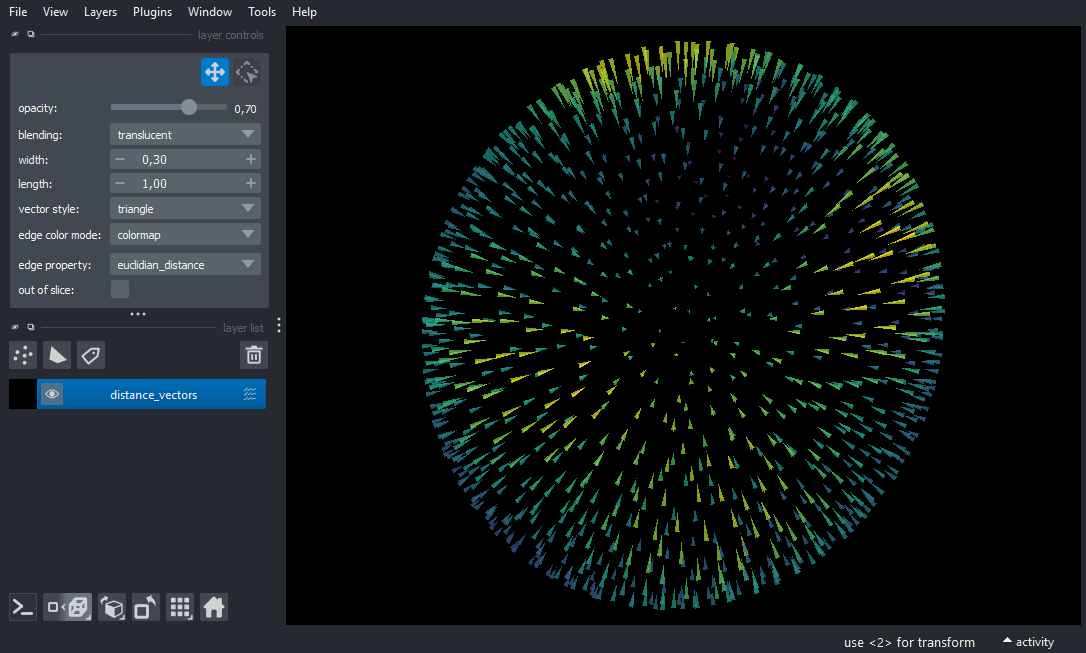

In [22]:
distance_vectors = vectors.pairwise_point_distances(pointcloud, fitted_points_vedo)

viewer.layers.clear()
viewer.add_vectors(distance_vectors, edge_width=0.3, edge_color='euclidian_distance', features={'euclidian_distance': expander.properties['residuals']})

napari.utils.nbscreenshot(viewer)

## Mean curvature on ellipsoid <a class="anchor" id="mean_curvature"></a>

Lastly, the curvature on the surface of an ellipsoid can be calculated esily with `measurements.curvature_on_ellipsoid`. *Note*: The bject returned from this function is of type `LayerDataTuple`, the structure of which is explained in the docstring. Use `help(measurements.curvature_on_ellipsoid)` to show.

In [23]:
result = measurements.curvature_on_ellipsoid(ellipsoid_stress, fitted_points_stress)

You can print the global curvatures on the ellipsoid: $H_e$ (average mean curvature $H_{e, 0}$ and maximal/minimal mean curvatures $H_{e, M}$ and  $H_{e, N}$)

In [24]:
for key in result[1]['metadata'].keys():
    print(key, ': ', result[1]['metadata'][key])

H0_ellipsoid :  0.06632935563610765
H_ellipsoid_major_medial_minor :  [0.08211623521128655, 0.06563346684877151, 0.05525323952731744]
frame :  [0]


Plot a histogram of curvatures...

Text(0.5, 0, 'Mean curvature')

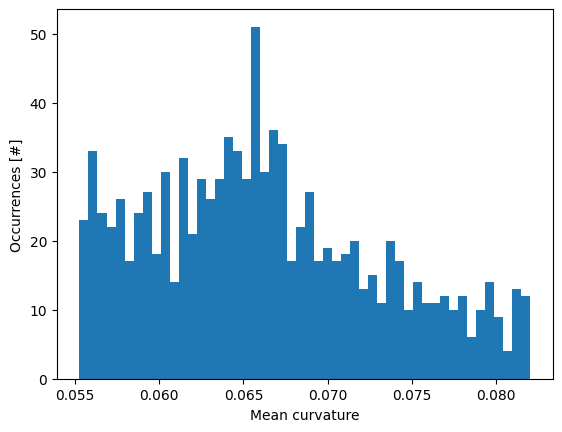

In [25]:
fig, ax = plt.subplots()
hist = ax.hist(result[1]['features']['mean_curvature'], 50)
ax.set_ylabel('Occurrences [#]')
ax.set_xlabel('Mean curvature')

...or visualize curvature in the napari viewer:

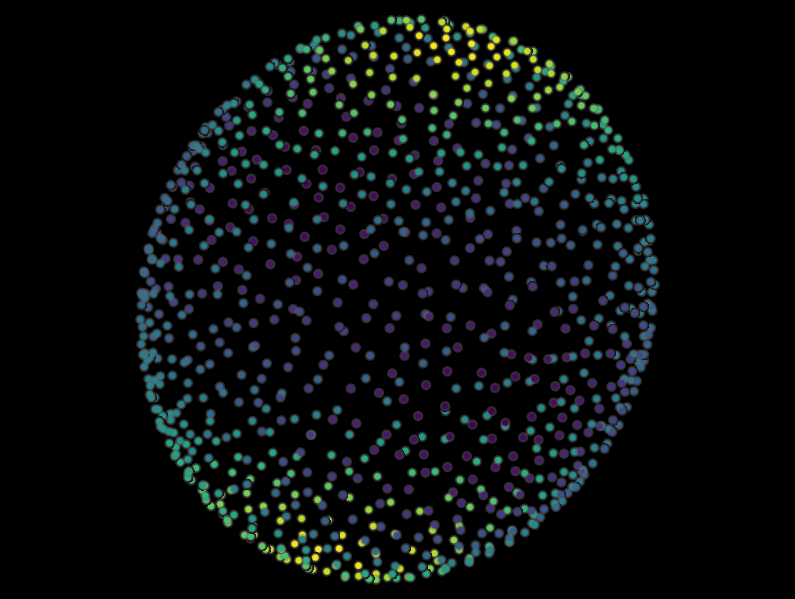

In [26]:
viewer.layers.clear()
viewer.add_points(result[0], **result[1])
napari.utils.nbscreenshot(viewer, canvas_only=True)